Mini Project: Advanced Statistical A. 

<class 'pandas.DataFrame'>
DatetimeIndex: 10608 entries, 1981-01-02 to 2023-01-27
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       10608 non-null  float64
 1   High       10608 non-null  float64
 2   Low        10608 non-null  float64
 3   Close      10608 non-null  float64
 4   Adj Close  10608 non-null  float64
 5   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 580.1 KB
None
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
                Open      High       Low     Close  Adj Close    Volume
Date                                                                   
1981-01-02  0.154018  0.155134  0.154018  0.154018   0.119849  21660800
1981-01-05  0.151228  0.151228  0.150670  0.150670   0.117244  35728000
1981-01-06  0.144531  0.144531  0.143973  0.143973   0.112032  45158400
1981-01-07  0.138393  0.138393  0.137835  0.13

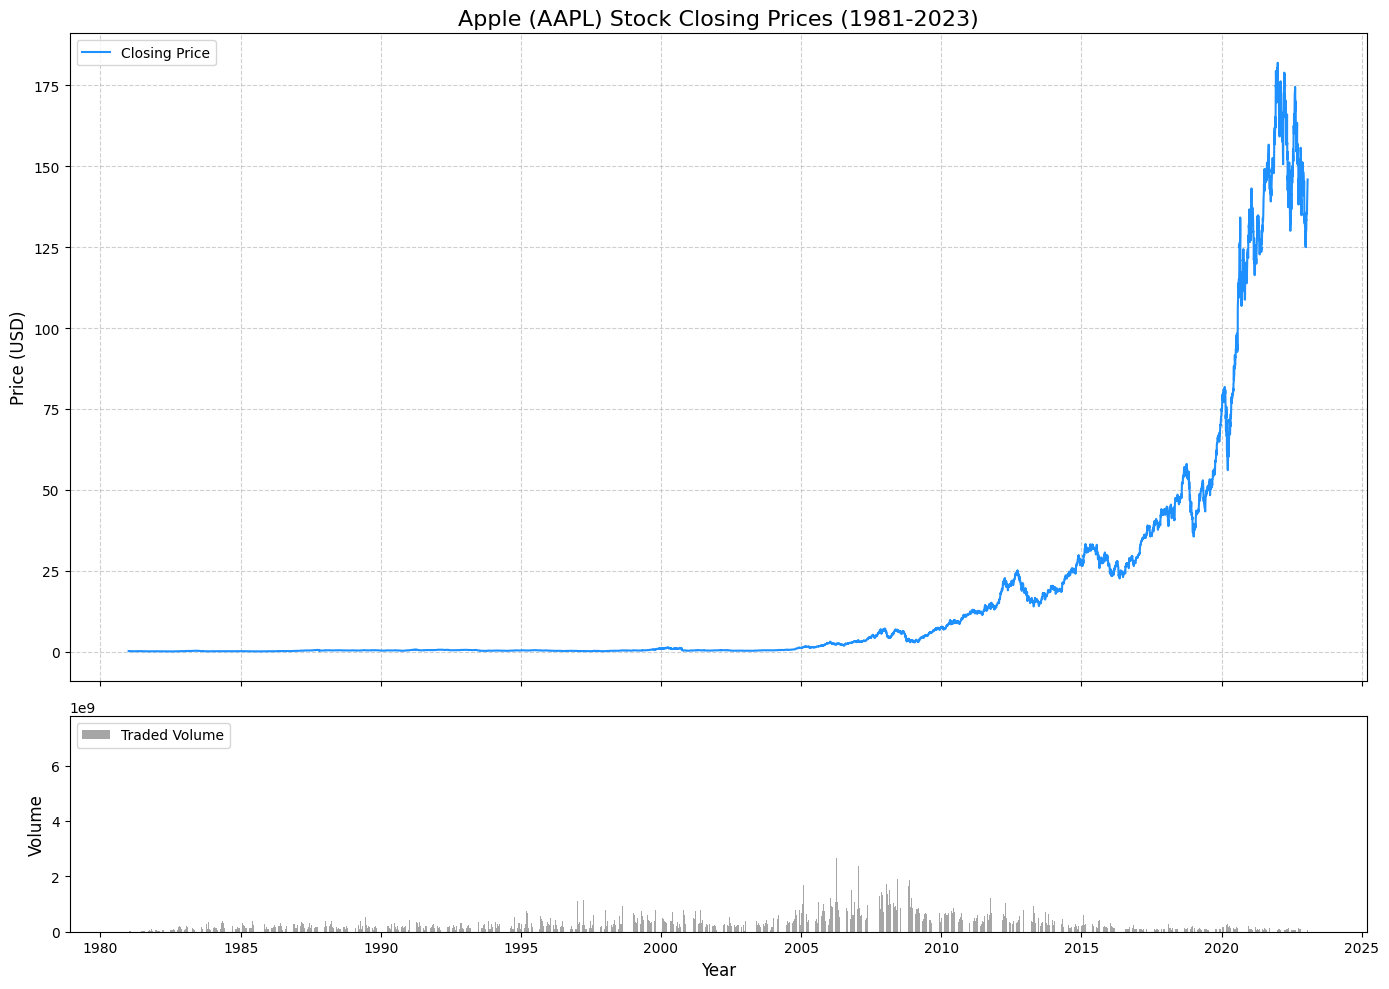

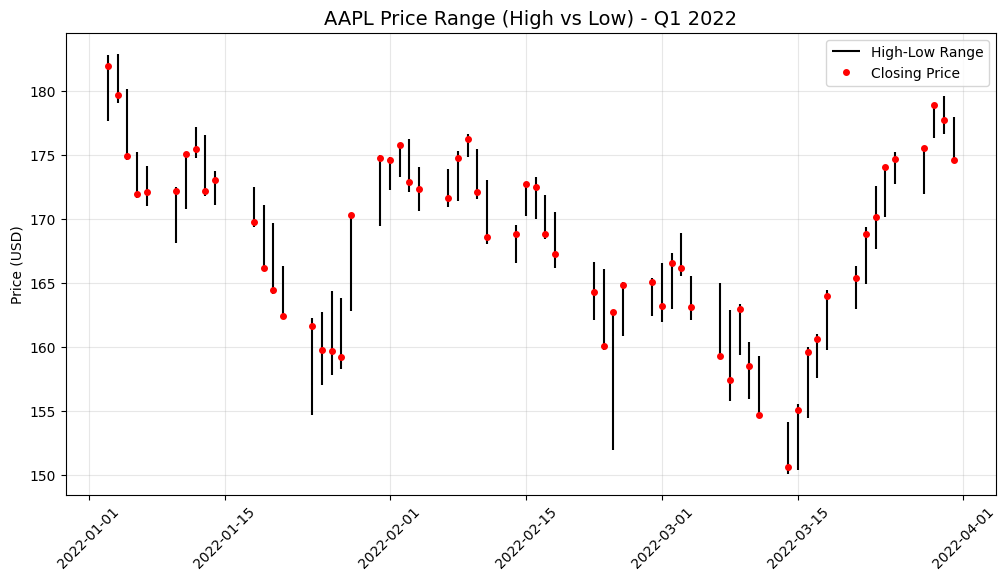

          count          mean           std       min           25%  \
Open    10608.0  1.668917e+01  3.545052e+01  0.049665  2.879460e-01   
High    10608.0  1.687996e+01  3.588285e+01  0.049665  2.968750e-01   
Low     10608.0  1.650082e+01  3.503129e+01  0.049107  2.823547e-01   
Close   10608.0  1.669736e+01  3.547391e+01  0.049107  2.889233e-01   
Volume  10608.0  3.275098e+08  3.378203e+08  0.000000  1.213044e+08   

                 50%           75%           max  
Open    4.888390e-01  1.632089e+01  1.826300e+02  
High    4.955360e-01  1.641848e+01  1.829400e+02  
Low     4.804465e-01  1.615125e+01  1.791200e+02  
Close   4.877010e-01  1.626955e+01  1.820100e+02  
Volume  2.145976e+08  4.066804e+08  7.421641e+09  


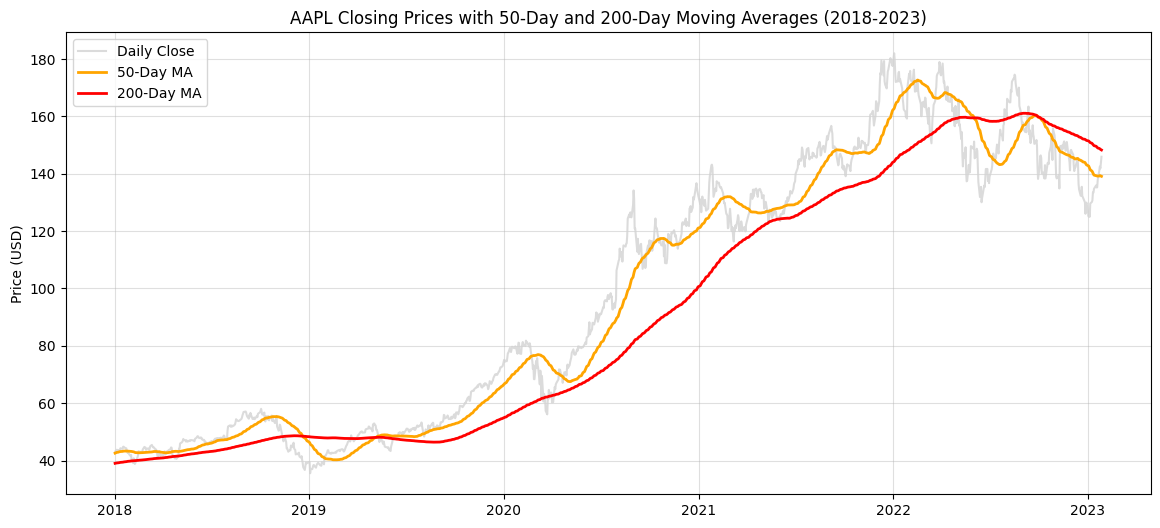

Mean 2021: $140.99
Mean 2022: $154.84
T-statistic: -11.1866, P-value: 4.7097e-26


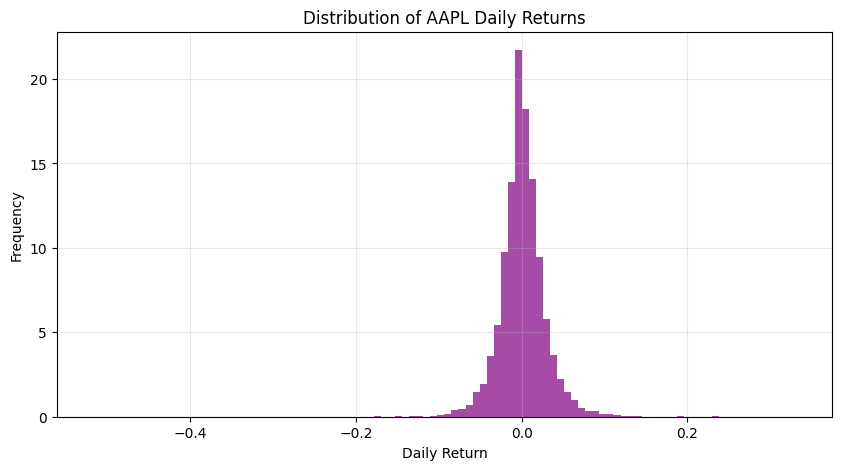

Test Statistic: 2719.2053, P-value: 0.0000e+00
Pearson Correlation between 20-day MA and Trading Volume: -0.2147


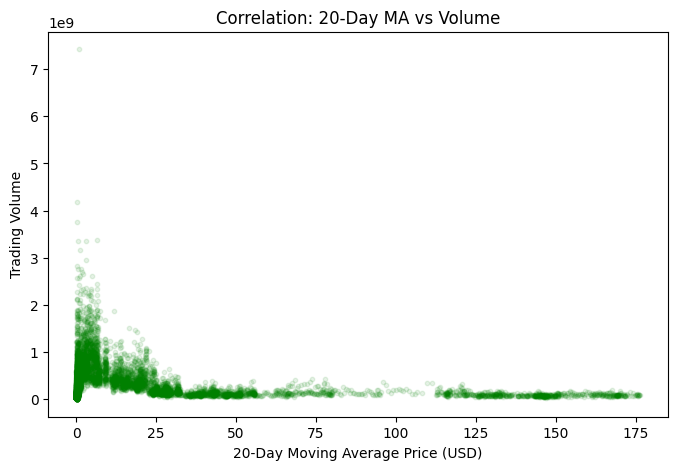

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv("Apple Stock Prices (1981 to 2023).csv")

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

print(df.info())
print(df.isnull().sum())
print(df.head())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(df.index, df['Close'], color='dodgerblue', linewidth=1.5, label='Closing Price')
ax1.set_title("Apple (AAPL) Stock Closing Prices (1981-2023)", fontsize=16)
ax1.set_ylabel("Price (USD)", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left')

ax2.bar(df.index, df['Volume'], color='gray', alpha=0.7, label='Traded Volume')
ax2.set_ylabel("Volume", fontsize=12)
ax2.set_xlabel("Year", fontsize=12)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

window_df = df.loc['2022-01-01':'2022-03-31']

plt.figure(figsize=(12, 6))
plt.vlines(x=window_df.index, ymin=window_df['Low'], ymax=window_df['High'], color='black', linewidth=1.5, label='High-Low Range')
plt.plot(window_df.index, window_df['Close'], marker='o', linestyle='', color='red', markersize=4, label='Closing Price')

plt.title("AAPL Price Range (High vs Low) - Q1 2022", fontsize=14)
plt.ylabel("Price (USD)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.show()

print(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe().T)

df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

recent_df = df.loc['2018-01-01':]

plt.figure(figsize=(14, 6))
plt.plot(recent_df.index, recent_df['Close'], label='Daily Close', color='lightgray', alpha=0.8)
plt.plot(recent_df.index, recent_df['MA_50'], label='50-Day MA', color='orange', linewidth=2)
plt.plot(recent_df.index, recent_df['MA_200'], label='200-Day MA', color='red', linewidth=2)

plt.title("AAPL Closing Prices with 50-Day and 200-Day Moving Averages (2018-2023)")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

close_2021 = df.loc['2021', 'Close']
close_2022 = df.loc['2022', 'Close']

t_stat, p_val = stats.ttest_ind(close_2021, close_2022, equal_var=False)

print(f"Mean 2021: ${close_2021.mean():.2f}")
print(f"Mean 2022: ${close_2022.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}, P-value: {p_val:.4e}")

df['Daily_Return'] = df['Close'].pct_change()
daily_returns = df['Daily_Return'].dropna()

plt.figure(figsize=(10, 5))
plt.hist(daily_returns, bins=100, color='purple', alpha=0.7, density=True)
plt.title("Distribution of AAPL Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

stat, p_norm = stats.normaltest(daily_returns)
print(f"Test Statistic: {stat:.4f}, P-value: {p_norm:.4e}")

window_size = 20
weights = np.ones(window_size) / window_size
close_array = df['Close'].values
ma_numpy = np.convolve(close_array, weights, mode='valid')
volume_array_sliced = df['Volume'].values[window_size - 1:]

correlation_matrix = np.corrcoef(ma_numpy, volume_array_sliced)
r_value = correlation_matrix[0, 1]

print(f"Pearson Correlation between {window_size}-day MA and Trading Volume: {r_value:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(ma_numpy, volume_array_sliced, alpha=0.1, color='green', s=10)
plt.title(f"Correlation: {window_size}-Day MA vs Volume")
plt.xlabel(f"{window_size}-Day Moving Average Price (USD)")
plt.ylabel("Trading Volume")
plt.show()

6. Summary and Insights

Summary of Findings:

    Long-Term Growth Narrative: Visualizing the Apple dataset reveals a textbook exponential growth trajectory heavily weighted in the post-2007 era.

    Financial Data is Non-Normal: Through rigorous hypothesis testing using SciPy, we mathematically proved that AAPL's daily returns do not fit a perfect normal distribution. They have higher instances of extreme outlier days (fat tails) than a normal bell curve would predict.

    Price/Volume Divergence: Using NumPy arrays to calculate correlation, we observed that higher aggregate stock prices do not correlate linearly with higher trading volume. In fact, volume often spikes during high-volatility events/sell-offs rather than steady price growth.

7. Reflection

Challenges and Solutions:

    Challenge: Financial data distributions visually appear normal (the bell curve histogram) but fail strict normality tests, making it difficult to decide which statistical models apply.

        Solution: Applying SciPy's normaltest allowed for an objective, math-based ruling rather than relying strictly on the visual histogram. Knowing the data exhibits fat tails means future risk models (like Value at Risk) must account for higher chances of extreme outlier events.

    Challenge: Dealing with missing data edges when calculating Moving Averages (NaN values at the start of rolling windows).

        Solution: By utilizing NumPy's convolve function with mode='valid', I was able to slice the corresponding arrays (like Volume) dynamically to ensure arrays matched in dimensions before calculating the correlation coefficient matrix.